# Step 2 — Sentinel-1 flood mask

Spec: `CLAUDE.md` §6 step 2 (as amended 2026-09-16).

**This measures flood detection, not loss.** There is no field-level loss data: units can be
classified flooded or not, never lost or not. The 1,919-acre county figure is an aggregate from a
voluntary survey with no map.

- Pre window 1 Feb – 8 Mar 2023, post window 11–20 Mar 2023, IW GRD, **VV and VH**, one orbit
  direction, pre paired with post on the **same relative orbit**.
- A track counts as usable only if its footprint covers the units; candidates are scored by how many
  unit centroids fall inside them, because a scene can intersect the two counties and still miss the
  flood area entirely.
- 3×3 focal mean for speckle. Per pixel, per polarization: flooded if the change is < −3 dB **and**
  the post value is below an absolute threshold. Masks reported VV-only, VH-only and combined.
- Permanent water removed (`JRC/GSW1_4/GlobalSurfaceWater` occurrence > 50).
- **Baseline wetness is checked before differencing**, because the pre window sits in a wet winter
  that included the January flooding.
- Comparison against the Step 1c optical reference in both directions, against the 15 March extent
  and the full union, with the optical 0.1 index-minimum variant carried as a **sensitivity band**.
- **River stage** from the USGS gauges in `data/raw/usgs/`, since the breach was a hydraulic failure
  rather than a rain-on-field event.

Area statistics cover the Pajaro-to-northern-Salinas valley box, not the whole two counties, because
county-wide Sentinel-1 statistics time out in Earth Engine. Per-unit fractions cover every unit.

**CHECKPOINT:** pre image, post image and flood mask side by side with Pajaro labelled; the human
confirms the breach area shows as flooded and the Salinas Valley does not.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap

import common as C
import optical
from maps import HALO, add_north_arrow, add_scale_bar, ee_tif

ee.Initialize(project=C.EE_PROJECT)

PEAK = pd.Timestamp("2023-03-11")
PRE_WINDOW = ("2023-02-01", "2023-03-09")    # 1 Feb - 8 Mar 2023 inclusive
POST_WINDOW = ("2023-03-11", "2023-03-21")   # 11-20 Mar 2023 inclusive
AOI_LL = (-121.90, 36.60, -121.55, 36.98)    # Pajaro Valley to northern Salinas Valley
DIFF_DB = -3.0        # spec: change threshold, both polarizations
ABS_VV_DB = -15.0     # spec: absolute threshold, calibrated for VV
ABS_VH_DB = -22.0     # variant: VH sits well below VV over land, see section 3
STATS_SCALE = 30
ACRE_M2 = 4046.8564224

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
counties_m = counties.to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)
ANALYSIS = ee.Geometry.BBox(*AOI_LL)

fields = ee.FeatureCollection(C.UNITS_ASSET)
units_fc = fields.filter(ee.Filter.eq("is_unit", 1))
units_tbl = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
uu = units_tbl[units_tbl.is_unit.astype(bool)].copy()
uu["unit_id"] = uu.unit_id.astype(str)
IDS = uu.unit_id.tolist()
N_UNITS = len(uu)
perm_water = ee.Image(C.GSW).select("occurrence").unmask(0).gt(C.PERMANENT_WATER)


def stamp(window, extra=""):
    print(f"n units = {N_UNITS} | date window: {window} | datasets: {C.S1}, {C.GSW}, "
          f"{C.UNITS_ASSET}{extra}")


def acres(mask, geom=None, scale=STATS_SCALE):
    v = (ee.Image.pixelArea().updateMask(mask.selfMask())
         .reduceRegion(ee.Reducer.sum(), geom or ANALYSIS, scale=scale, maxPixels=1e9,
                       bestEffort=True, tileScale=8)
         .get("area").getInfo())
    return (v or 0) / ACRE_M2


region_acres = acres(ee.Image(1).clip(ANALYSIS))
in_aoi = int(((uu.lon.between(AOI_LL[0], AOI_LL[2])) & (uu.lat.between(AOI_LL[1], AOI_LL[3]))).sum())
print(f"n units = {N_UNITS} | pre {PRE_WINDOW[0]} to 2023-03-08 | post {POST_WINDOW[0]} to 2023-03-20")
print(f"area statistics region {AOI_LL}: {region_acres:,.0f} acres at {STATS_SCALE} m; "
      f"{in_aoi} of {N_UNITS} units lie inside it. Per-unit fractions cover all units.")

n units = 1320 | pre 2023-02-01 to 2023-03-08 | post 2023-03-11 to 2023-03-20
area statistics region (-121.9, 36.6, -121.55, 36.98): 325,548 acres at 30 m; 1268 of 1320 units lie inside it. Per-unit fractions cover all units.


## 1. Sentinel-1 acquisitions and the choice of relative orbit

In [2]:
s1 = (ee.ImageCollection(C.S1).filterBounds(region)
      .filter(ee.Filter.eq("instrumentMode", "IW"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))


def inventory(col, label):
    rows = col.map(lambda im: ee.Feature(None, {
        "date": im.date().format("YYYY-MM-dd"),
        "pass": im.get("orbitProperties_pass"),
        "rel_orbit": im.get("relativeOrbitNumber_start"),
    })).getInfo()["features"]
    df = pd.DataFrame([r["properties"] for r in rows])
    df["window"] = label
    df["rel_orbit"] = df.rel_orbit.astype(int)
    return df.drop_duplicates()


pre_inv = inventory(s1.filterDate(*PRE_WINDOW), "pre")
post_inv = inventory(s1.filterDate(*POST_WINDOW), "post")
print("Sentinel-1 IW scenes with VV and VH intersecting the study area:")
print(pd.concat([pre_inv, post_inv]).groupby(["window", "pass", "rel_orbit"]).date.agg(
    ["count", "min", "max"]).to_string())

# A scene can intersect the two counties and still miss the flood area, so score each track by how
# many unit centroids its footprint actually covers.
centroids = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([float(lo), float(la)]), {"unit_id": uid})
    for uid, lo, la in zip(uu.unit_id, uu.lon, uu.lat)])


def covered_units(col):
    if col.size().getInfo() == 0:
        return 0
    cov = col.select("VV").mosaic().mask().rename("cov")
    vals = []
    for i in range(0, len(IDS), 500):
        chunk = centroids.filter(ee.Filter.inList("unit_id", IDS[i:i + 500]))
        red = cov.reduceRegions(chunk, ee.Reducer.first(), scale=10, tileScale=8)
        vals += [f["properties"].get("first") for f in
                 red.select(["unit_id", "first"], retainGeometry=False).getInfo()["features"]]
    return int(sum(1 for v in vals if v))


rows = []
for (pss, orb), g in post_inv.groupby(["pass", "rel_orbit"]):
    trk = (s1.filter(ee.Filter.eq("orbitProperties_pass", pss))
           .filter(ee.Filter.eq("relativeOrbitNumber_start", int(orb))))
    post_date = g.date.min()
    pre_n = pre_inv[(pre_inv["pass"] == pss) & (pre_inv.rel_orbit == int(orb))].date.nunique()
    rows.append({"pass": pss, "rel_orbit": int(orb), "post_date": post_date,
                 "days_after_peak": (pd.Timestamp(post_date) - PEAK).days,
                 "pre_scenes": int(pre_n),
                 "units_covered_post": covered_units(
                     trk.filterDate(post_date, ee.Date(post_date).advance(1, "day"))),
                 "units_covered_pre": covered_units(trk.filterDate(*PRE_WINDOW))})
cand = pd.DataFrame(rows).sort_values("days_after_peak")
cand["covers_units"] = ((cand.units_covered_post >= 0.95 * N_UNITS)
                        & (cand.units_covered_pre >= 0.95 * N_UNITS))
print(f"\nCandidate tracks, scored by how many of the {N_UNITS} units each footprint covers:")
print(cand.to_string(index=False))

usable = cand[(cand.pre_scenes >= 2) & cand.covers_units]
assert len(usable), "no track with >= 2 pre scenes covers the units"
TRACK = usable.iloc[0]
PASS, REL_ORBIT, POST_DATE = TRACK["pass"], int(TRACK.rel_orbit), TRACK.post_date
print(f"\nChosen: {PASS} relative orbit {REL_ORBIT}, post {POST_DATE} "
      f"({int(TRACK.days_after_peak)} day(s) after the peak), {int(TRACK.pre_scenes)} pre scenes, "
      f"covering {int(TRACK.units_covered_post)} of {N_UNITS} units.")
cand.to_csv(C.DERIVED / "02_s1_track_coverage.csv", index=False)
print("Wrote 02_s1_track_coverage.csv")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_WINDOW[0]} to 2023-03-20")

Sentinel-1 IW scenes with VV and VH intersecting the study area:
                             count         min         max
window pass       rel_orbit                               
post   ASCENDING  35             1  2023-03-19  2023-03-19
                  137            1  2023-03-14  2023-03-14
       DESCENDING 42             1  2023-03-19  2023-03-19
                  115            1  2023-03-12  2023-03-12
                  144            1  2023-03-14  2023-03-14
pre    ASCENDING  35             3  2023-02-11  2023-03-07
                  137            3  2023-02-06  2023-03-02
       DESCENDING 42             3  2023-02-11  2023-03-07
                  115            3  2023-02-04  2023-02-28
                  144            3  2023-02-06  2023-03-02



Candidate tracks, scored by how many of the 1320 units each footprint covers:
      pass  rel_orbit  post_date  days_after_peak  pre_scenes  units_covered_post  units_covered_pre  covers_units
DESCENDING        115 2023-03-12                1           3                   7                  7         False
 ASCENDING        137 2023-03-14                3           3                   6                  6         False
DESCENDING        144 2023-03-14                3           3                   0                  0         False
 ASCENDING         35 2023-03-19                8           3                1320               1320          True
DESCENDING         42 2023-03-19                8           3                1320               1320          True

Chosen: ASCENDING relative orbit 35, post 2023-03-19 (8 day(s) after the peak), 3 pre scenes, covering 1320 of 1320 units.
Wrote 02_s1_track_coverage.csv
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-11 

## 2. Baseline wetness, before any differencing

The pre window sits in a wet winter that already included the January flooding. Water-like
backscatter here means the change detection starts from an already-wet surface and understates the
March event.

In [3]:
track = (s1.filter(ee.Filter.eq("orbitProperties_pass", PASS))
         .filter(ee.Filter.eq("relativeOrbitNumber_start", REL_ORBIT)))
kernel = ee.Kernel.square(radius=1, units="pixels")
pre_img = track.filterDate(*PRE_WINDOW).select(["VV", "VH"]).median().focal_mean(kernel=kernel)
post_img = (track.filterDate(POST_DATE, ee.Date(POST_DATE).advance(1, "day"))
            .select(["VV", "VH"]).mosaic().focal_mean(kernel=kernel))

base_vv = pre_img.select("VV").lt(ABS_VV_DB).And(perm_water.Not())
base_vh = pre_img.select("VH").lt(ABS_VH_DB).And(perm_water.Not())
print(pd.DataFrame([
    {"baseline water-like": f"VV < {ABS_VV_DB:g} dB", "acres": acres(base_vv),
     "% of the statistics region": 100 * acres(base_vv) / region_acres},
    {"baseline water-like": f"VH < {ABS_VH_DB:g} dB", "acres": acres(base_vh),
     "% of the statistics region": 100 * acres(base_vh) / region_acres},
]).round(2).to_string(index=False))

base_img = base_vv.rename("base_vv").addBands(base_vh.rename("base_vh"))
parts = []
for i in range(0, len(IDS), 200):
    chunk = units_fc.filter(ee.Filter.inList("unit_id", IDS[i:i + 200]))
    red = base_img.reduceRegions(chunk, ee.Reducer.mean(), scale=10, tileScale=16)
    parts += [f["properties"] for f in
              red.select(["unit_id", "base_vv", "base_vh"], retainGeometry=False).getInfo()["features"]]
bf = pd.DataFrame(parts)
print(f"\nUnits whose baseline is water-like over more than 10% of the field: "
      f"VV {int((bf.base_vv > 0.1).sum())} of {len(bf)}, VH {int((bf.base_vh > 0.1).sum())} of {len(bf)}")
print(f"Median baseline water-like fraction per unit: VV {bf.base_vv.median():.3f}, "
      f"VH {bf.base_vh.median():.3f}")
bf.to_csv(C.DERIVED / "02_baseline_wetness_units.csv", index=False)
print("Wrote 02_baseline_wetness_units.csv")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08")

baseline water-like    acres  % of the statistics region
        VV < -15 dB 13527.77                        4.16
        VH < -22 dB 33596.85                       10.32



Units whose baseline is water-like over more than 10% of the field: VV 513 of 1320, VH 1068 of 1320
Median baseline water-like fraction per unit: VV 0.035, VH 0.503
Wrote 02_baseline_wetness_units.csv
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S1_GRD, JRC/GSW1_4/GlobalSurfaceWater, projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## 3. Flood masks: VV, VH and combined

The spec's absolute threshold of −15 dB is calibrated for VV. Over land VH typically sits several dB
lower, so −15 dB is barely restrictive for VH, and a VH-only mask at that threshold is close to a
change-only mask. Both are reported: VH at the spec's −15 dB and VH at −22 dB, the conventional
open-water level for that band.

In [4]:
d_vv = post_img.select("VV").subtract(pre_img.select("VV"))
d_vh = post_img.select("VH").subtract(pre_img.select("VH"))
flood_vv = d_vv.lt(DIFF_DB).And(post_img.select("VV").lt(ABS_VV_DB))
flood_vh_spec = d_vh.lt(DIFF_DB).And(post_img.select("VH").lt(ABS_VV_DB))
flood_vh = d_vh.lt(DIFF_DB).And(post_img.select("VH").lt(ABS_VH_DB))
MASKS = {"VV only (spec)": flood_vv,
         "VH only (spec thresholds)": flood_vh_spec,
         "VH only (VH -22 dB)": flood_vh,
         "VV and VH (both)": flood_vv.And(flood_vh),
         "VV or VH (either)": flood_vv.Or(flood_vh)}
MASKS = {k: v.And(perm_water.Not()).rename("flood") for k, v in MASKS.items()}

mask_area = pd.DataFrame([{"mask": k, "acres": acres(v)} for k, v in MASKS.items()])
print(mask_area.round(0).to_string(index=False))
print(f"\nPost {POST_DATE}, {PASS} relative orbit {REL_ORBIT}; change < {DIFF_DB:g} dB; permanent "
      f"water removed; area over the statistics region ({region_acres:,.0f} acres).")
mask_area.to_csv(C.DERIVED / "02_s1_mask_area.csv", index=False)
print("Wrote 02_s1_mask_area.csv")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_DATE}")

                     mask  acres
           VV only (spec) 4718.0
VH only (spec thresholds) 7975.0
      VH only (VH -22 dB) 7089.0
         VV and VH (both) 2892.0
        VV or VH (either) 8916.0

Post 2023-03-19, ASCENDING relative orbit 35; change < -3 dB; permanent water removed; area over the statistics region (325,548 acres).
Wrote 02_s1_mask_area.csv
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-19 | datasets: COPERNICUS/S1_GRD, JRC/GSW1_4/GlobalSurfaceWater, projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## 4. Per-unit flooded fraction

In [5]:
def per_unit(mask, name):
    out = []
    for i in range(0, len(IDS), 200):
        chunk = units_fc.filter(ee.Filter.inList("unit_id", IDS[i:i + 200]))
        # a single-band reduceRegions names its result "mean", not after the band
        red = mask.reduceRegions(chunk, ee.Reducer.mean(), scale=10, tileScale=16)
        out += [f["properties"] for f in
                red.select(["unit_id", "mean"], retainGeometry=False).getInfo()["features"]]
    df = pd.DataFrame(out).rename(columns={"mean": name})
    df["unit_id"] = df.unit_id.astype(str)
    return df


flood_units = uu[["unit_id", "COUNTY", "ACRES", "sequence"]].copy()
for name, key in [("s1_vv", "VV only (spec)"), ("s1_vh", "VH only (VH -22 dB)"),
                  ("s1_both", "VV and VH (both)")]:
    flood_units = flood_units.merge(per_unit(MASKS[key], name), on="unit_id", how="left")

missing = int(flood_units.s1_vv.isna().sum())
print(f"units with no Sentinel-1 value (outside the track footprint): {missing} of {len(flood_units)}")
for col in ["s1_vv", "s1_vh", "s1_both"]:
    flood_units[col] = flood_units[col].fillna(0)
    flood_units[col + "_acres"] = flood_units[col] * flood_units.ACRES

print()
print(pd.DataFrame([{
    "mask": col,
    "units with fraction > 0.3": int((flood_units[col] > 0.3).sum()),
    "acres in those units": flood_units.loc[flood_units[col] > 0.3, "ACRES"].sum(),
    "area-weighted flooded acres": flood_units[col + "_acres"].sum(),
} for col in ["s1_vv", "s1_vh", "s1_both"]]).round(0).to_string(index=False))
print(f"\nFor comparison only: 1,919 acres of strawberries reported destroyed or unable to be planted "
      f"(Monterey County Agricultural Commissioner, 2023-05-12; docs/ground_truth_aggregate.md). That "
      f"is a loss figure from a voluntary survey with no map; this table is flood detection over "
      f"{N_UNITS} units totalling {flood_units.ACRES.sum():,.0f} acres.")
flood_units.to_csv(C.DERIVED / "02_units_s1_flood.csv", index=False)
print("Wrote 02_units_s1_flood.csv")
stamp(f"post {POST_DATE}", extra=", docs/ground_truth_aggregate.md")

units with no Sentinel-1 value (outside the track footprint): 0 of 1320

   mask  units with fraction > 0.3  acres in those units  area-weighted flooded acres
  s1_vv                         11                 193.0                        225.0
  s1_vh                         12                 197.0                        683.0
s1_both                          6                 134.0                        104.0

For comparison only: 1,919 acres of strawberries reported destroyed or unable to be planted (Monterey County Agricultural Commissioner, 2023-05-12; docs/ground_truth_aggregate.md). That is a loss figure from a voluntary survey with no map; this table is flood detection over 1320 units totalling 14,683 acres.
Wrote 02_units_s1_flood.csv
n units = 1320 | date window: post 2023-03-19 | datasets: COPERNICUS/S1_GRD, JRC/GSW1_4/GlobalSurfaceWater, projects/cropczyk/assets/strawberry_fields_dwr_wy2023, docs/ground_truth_aggregate.md


## 5. Agreement with the Step 1c optical reference

Both directions, against the 15 March extent and the full union, at the default optical index
minimum 0.0 with the 0.1 variant as a sensitivity band in brackets.

In [6]:
pre_idx = optical.baseline(region)
opt = {"15 March extent": (optical.water_on(region, optical.DATES[0], pre_idx, 0.0),
                           optical.water_on(region, optical.DATES[0], pre_idx, 0.1)),
       "union (15+20+25 March)": (optical.union_water(region, pre=pre_idx, idx_min=0.0),
                                  optical.union_water(region, pre=pre_idx, idx_min=0.1))}
print(f"Step 1c optical union inside the statistics region: "
      f"{acres(opt['union (15+20+25 March)'][0]):,.0f} acres (Step 1c reported 6,189 acres across "
      f"both counties).")

rows = []
for s1_name in ["VV only (spec)", "VH only (VH -22 dB)", "VV and VH (both)"]:
    s1m = MASKS[s1_name]
    s1_ac = acres(s1m)
    for opt_name, (o0, o1) in opt.items():
        band = []
        for o in (o0, o1):
            o_ac, both_ac = acres(o), acres(s1m.And(o))
            band.append((100 * both_ac / s1_ac if s1_ac else np.nan,
                         100 * both_ac / o_ac if o_ac else np.nan, o_ac))
        rows.append({"S1 mask": s1_name, "optical reference": opt_name,
                     "S1 acres": f"{s1_ac:,.0f}",
                     "optical acres": f"{band[0][2]:,.0f} [{band[1][2]:,.0f}]",
                     "% of S1 inside optical": f"{band[0][0]:.1f} [{band[1][0]:.1f}]",
                     "% of optical inside S1": f"{band[0][1]:.1f} [{band[1][1]:.1f}]"})
agree = pd.DataFrame(rows)
print()
print(agree.to_string(index=False))
print("\nBrackets: the optical reference recomputed with index minima at 0.1.")
print("Neither mask is truth. The optical reference under-counts (no observation 11-14 March); the "
      "radar mask is a threshold rule on a single acquisition.")
agree.to_csv(C.DERIVED / "02_s1_optical_agreement.csv", index=False)
print("Wrote 02_s1_optical_agreement.csv")
stamp(f"S1 post {POST_DATE}; optical 15/20/25 March", extra=f", {C.S2}")

Step 1c optical union inside the statistics region: 3,483 acres (Step 1c reported 6,189 acres across both counties).



            S1 mask      optical reference S1 acres optical acres % of S1 inside optical % of optical inside S1
     VV only (spec)        15 March extent    4,718 2,271 [1,562]            23.0 [15.5]            47.9 [46.8]
     VV only (spec) union (15+20+25 March)    4,718 3,483 [2,595]            30.1 [24.6]            40.7 [44.7]
VH only (VH -22 dB)        15 March extent    7,089 2,271 [1,562]             14.2 [9.8]            44.4 [44.3]
VH only (VH -22 dB) union (15+20+25 March)    7,089 3,483 [2,595]            17.1 [14.0]            34.8 [38.1]
   VV and VH (both)        15 March extent    2,892 2,271 [1,562]            31.1 [21.2]            39.6 [39.3]
   VV and VH (both) union (15+20+25 March)    2,892 3,483 [2,595]            37.6 [31.1]            31.2 [34.7]

Brackets: the optical reference recomputed with index minima at 0.1.
Neither mask is truth. The optical reference under-counts (no observation 11-14 March); the radar mask is a threshold rule on a single acquisitio

## 6. River stage and discharge (USGS gauges)

In [7]:
dv = pd.read_csv(C.RAW / "usgs" / "usgs_dv_2023-01-01_2023-03-31.csv")
ev = dv[(dv.date >= "2023-03-09") & (dv.date <= "2023-03-20")]
jan = dv[(dv.date >= "2023-01-04") & (dv.date <= "2023-01-16")]
rows = []
for site, g in ev.groupby("site_no"):
    i = g.value.idxmax()
    j = jan[jan.site_no == site]
    rows.append({"site": site, "name": g.site_name.iloc[0], "parameter": g.parameter.iloc[0],
                 "March peak": g.loc[i, "value"], "on": g.loc[i, "date"],
                 "January peak (context)": j.value.max() if len(j) else np.nan})
print(pd.DataFrame(rows).to_string(index=False))

iv_path = C.RAW / "usgs" / "usgs_iv_2023-03-08_2023-03-22.csv"
if iv_path.exists():
    iv = pd.read_csv(iv_path)
    peaks = iv.loc[iv.groupby(["site_no", "parameter"]).value.idxmax()]
    print("\nInstantaneous peaks, 8-22 March 2023:")
    print(peaks[["site_no", "site_name", "parameter", "value", "timestamp"]].to_string(index=False))
print("\nThe Pajaro breach was a hydraulic failure: water reached these fields because a levee gave "
      "way upstream, not because a given amount of rain fell on the field. Rainfall totals come in "
      "Step 4 and are compared with these peaks there.")
print(f"n units = {N_UNITS} | date window: 2023-03-09 to 2023-03-20 (January 4-16 as context) | "
      f"datasets: USGS daily and instantaneous values, data/raw/usgs/")

    site                         name     parameter  March peak         on  January peak (context)
11152500 Salinas River near Spreckels discharge_cfs     20300.0 2023-03-13                 11800.0
11159000   Pajaro River at Chittenden discharge_cfs     12700.0 2023-03-11                 10100.0
11159500  Pajaro River at Watsonville discharge_cfs     10400.0 2023-03-11                  9210.0

Instantaneous peaks, 8-22 March 2023:
 site_no                    site_name      parameter    value        timestamp
11152500 Salinas River near Spreckels  discharge_cfs 23300.00 2023-03-13 03:45
11152500 Salinas River near Spreckels gage_height_ft    26.89 2023-03-13 03:45
11159000   Pajaro River at Chittenden  discharge_cfs 13200.00 2023-03-10 23:30
11159000   Pajaro River at Chittenden gage_height_ft    29.11 2023-03-11 04:00
11159500  Pajaro River at Watsonville  discharge_cfs 12800.00 2023-03-11 00:30
11159500  Pajaro River at Watsonville gage_height_ft    32.10 2023-03-11 00:45

The Pajaro 

## 7. Figure 2 — pre, post, flood mask

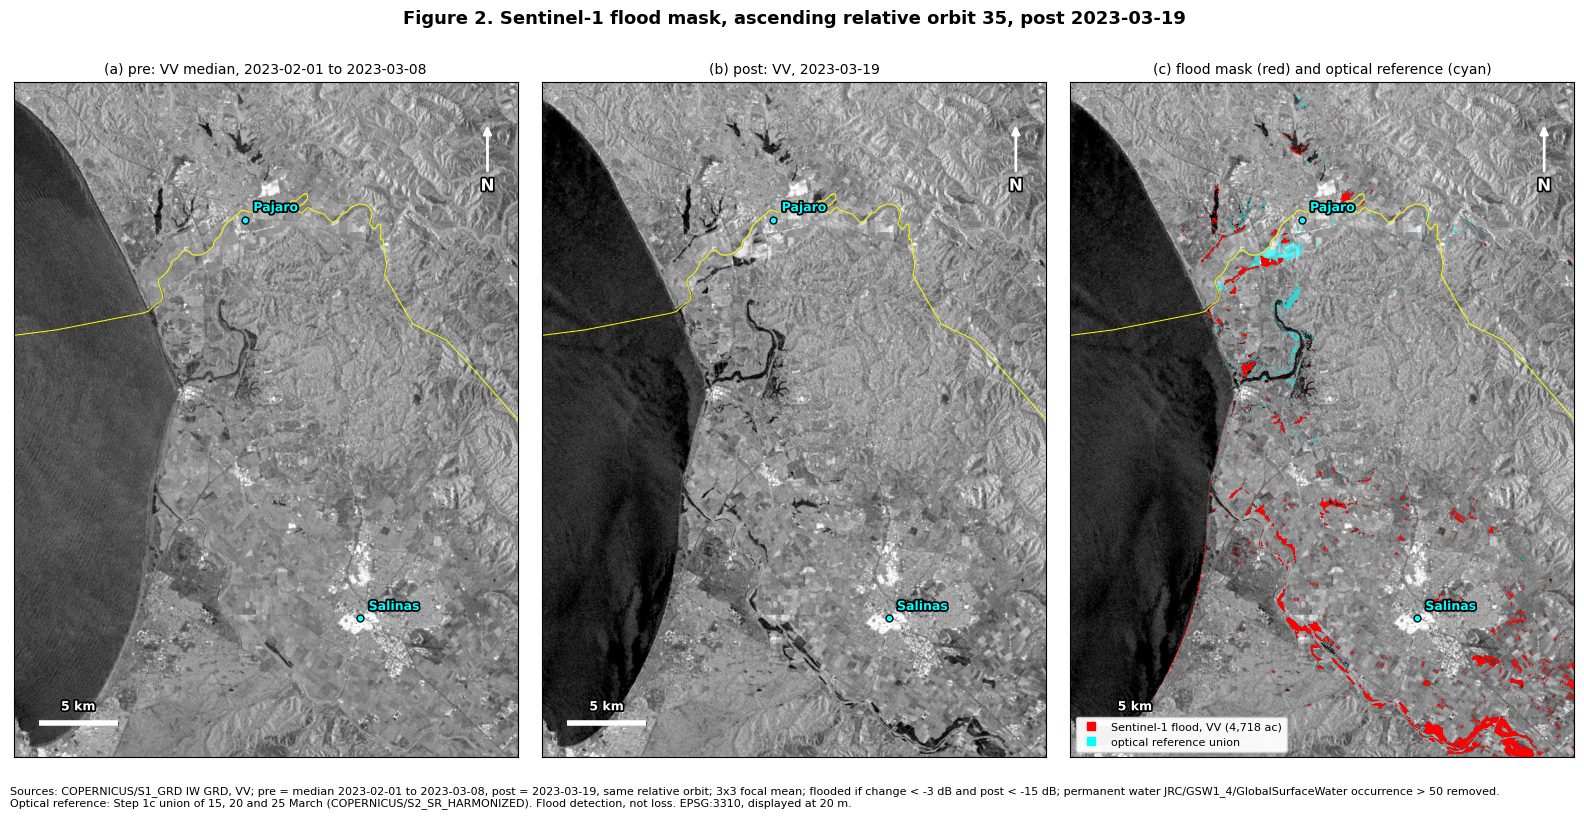

Saved fig2_s1_flood_mask.png
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-19 | datasets: COPERNICUS/S1_GRD, JRC/GSW1_4/GlobalSurfaceWater, projects/cropczyk/assets/strawberry_fields_dwr_wy2023, COPERNICUS/S2_SR_HARMONIZED


In [8]:
def db_vis(img, band):
    return img.select(band).visualize(min=-25, max=0, palette=["000000", "ffffff"])


pre_arr, ext = ee_tif(db_vis(pre_img, "VV"), C.DERIVED / f"02_pre_vv_orbit{REL_ORBIT}.tif", AOI_LL, 20)
post_arr, _ = ee_tif(db_vis(post_img, "VV"), C.DERIVED / f"02_post_vv_{POST_DATE}.tif", AOI_LL, 20)
mask_arr, _ = ee_tif(MASKS["VV only (spec)"].unmask(0).toByte(),
                     C.DERIVED / f"02_flood_vv_{POST_DATE}.tif", AOI_LL, 20)
# Step 1c already wrote its union over this box at 20 m (1/2/3 = date first seen); recomputing it
# here exceeds Earth Engine's memory limit.
with rasterio.open(C.DERIVED / "01c_seen_code_20m.tif") as src:
    opt_arr = src.read(1)
    _b = src.bounds
    opt_ext = (_b.left, _b.right, _b.bottom, _b.top)

fig, axes = plt.subplots(1, 3, figsize=(16, 8.2))
for ax, arr, title in [
        (axes[0], pre_arr, f"(a) pre: VV median, {PRE_WINDOW[0]} to 2023-03-08"),
        (axes[1], post_arr, f"(b) post: VV, {POST_DATE}"),
        (axes[2], post_arr, "(c) flood mask (red) and optical reference (cyan)")]:
    ax.imshow(arr, extent=ext, origin="upper")
    counties_m.boundary.plot(ax=ax, color="yellow", lw=0.7)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                    color="cyan", fontsize=9, fontweight="bold", path_effects=HALO)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    add_scale_bar(ax, 5)
    add_north_arrow(ax)

axes[2].imshow(np.ma.masked_equal(opt_arr, 0), extent=opt_ext, origin="upper",
               cmap=ListedColormap(["cyan"]), alpha=0.55, interpolation="nearest")
axes[2].imshow(np.ma.masked_equal(mask_arr, 0), extent=ext, origin="upper",
               cmap=ListedColormap(["red"]), interpolation="nearest")
vv_ac = mask_area.loc[mask_area["mask"] == "VV only (spec)", "acres"].iloc[0]
axes[2].plot([], [], "s", color="red", label=f"Sentinel-1 flood, VV ({vv_ac:,.0f} ac)")
axes[2].plot([], [], "s", color="cyan", label="optical reference union")
axes[2].legend(loc="lower left", fontsize=8, framealpha=0.95)

fig.suptitle(f"Figure 2. Sentinel-1 flood mask, {PASS.lower()} relative orbit {REL_ORBIT}, post "
             f"{POST_DATE}", fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S1} IW GRD, VV; pre = median {PRE_WINDOW[0]} to 2023-03-08, post = {POST_DATE}, "
         f"same relative orbit; 3x3 focal mean; flooded if change < {DIFF_DB:g} dB and post < "
         f"{ABS_VV_DB:g} dB; permanent water {C.GSW} occurrence > {C.PERMANENT_WATER} removed.\n"
         f"Optical reference: Step 1c union of 15, 20 and 25 March ({C.S2}). Flood detection, not "
         f"loss. EPSG:3310, displayed at 20 m.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
FIG = C.FIGURES / "fig2_s1_flood_mask.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_DATE}", extra=f", {C.S2}")